# Week 1 Artifact - DuckDB Exploration with NYC Taxi Data

## Overview

This notebook explores the use of DuckDB as a lightweight analytical database for working with large local datasets.

The NYC Taxi dataset contains millions of trip records stored across multiple CSV files. Instead of loading these files directly into memory with pandas, DuckDB allows analytical SQL queries to run directly against the data or materialize it into a fast local database.

This notebook demonstrates how to:

- Query multiple CSV files as a single dataset
- Create a persistent DuckDB database
- Inspect and profile the dataset
- Create a cleaned analytical view
- Run exploratory analytical queries

## Objective

The goal of this experiment is to evaluate DuckDB as a local analytical engine for large datasets.

Specifically:

1. Load multiple CSV files into a DuckDB database
2. Explore the schema and structure of the taxi dataset
3. Identify potential anomalies or outliers
4. Create a cleaned analytical dataset
5. Perform simple exploratory analysis

This exercise serves as the first artifact in a larger research curriculum focused on modern data systems.

## Dataset

Dataset: NYC Yellow Taxi Trip Data

Files used:

- yellow_tripdata_2015-01.csv
- yellow_tripdata_2016-01.csv
- yellow_tripdata_2016-02.csv
- yellow_tripdata_2016-03.csv

Each row represents a single taxi trip and includes fields such as:

- passenger_count
- trip_distance
- fare_amount
- tip_amount
- total_amount
- pickup and dropoff timestamps

## Environment Setup

The analysis environment includes:

- DuckDB
- Python
- Jupyter Notebook

DuckDB is used as the analytical engine to query and store the taxi dataset locally.

In [3]:
import duckdb

query = """
SELECT *
FROM read_csv_auto('../data/nyc_taxi/*.csv', union_by_name=True)
LIMIT 10
"""

duckdb.sql(query).df()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,N,-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.00,0.3,17.05
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.30,-74.001648,40.724243,1,N,-73.994415,40.759109,1,14.5,0.5,0.5,2.00,0.00,0.3,17.80
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.80,-73.963341,40.802788,1,N,-73.951820,40.824413,2,9.5,0.5,0.5,0.00,0.00,0.3,10.80
3,1,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.50,-74.009087,40.713818,1,N,-74.004326,40.719986,2,3.5,0.5,0.5,0.00,0.00,0.3,4.80
4,1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.00,-73.971176,40.762428,1,N,-74.004181,40.742653,2,15.0,0.5,0.5,0.00,0.00,0.3,16.30
5,1,2015-01-10 20:33:39,2015-01-10 20:53:52,1,9.00,-73.874374,40.774048,1,N,-73.986977,40.758194,1,27.0,0.5,0.5,6.70,5.33,0.3,40.33
6,1,2015-01-10 20:33:39,2015-01-10 20:58:31,1,2.20,-73.983276,40.726009,1,N,-73.992470,40.749634,2,14.0,0.5,0.5,0.00,0.00,0.3,15.30
7,1,2015-01-10 20:33:39,2015-01-10 20:42:20,3,0.80,-74.002663,40.734142,1,N,-73.995010,40.726326,1,7.0,0.5,0.5,1.66,0.00,0.3,9.96
8,1,2015-01-10 20:33:39,2015-01-10 21:11:35,3,18.20,-73.783043,40.644356,2,N,-73.987595,40.759357,2,52.0,0.0,0.5,0.00,5.33,0.3,58.13
9,1,2015-01-10 20:33:40,2015-01-10 20:40:44,2,0.90,-73.985588,40.767948,1,N,-73.985916,40.759365,1,6.5,0.5,0.5,1.55,0.00,0.3,9.35


In [4]:
import glob

glob.glob("../data/nyc_taxi/*.csv")

['../data/nyc_taxi\\yellow_tripdata_2015-01.csv',
 '../data/nyc_taxi\\yellow_tripdata_2016-01.csv',
 '../data/nyc_taxi\\yellow_tripdata_2016-02.csv',
 '../data/nyc_taxi\\yellow_tripdata_2016-03.csv']

In [5]:
duckdb.sql("""
CREATE OR REPLACE VIEW taxi_trips AS
SELECT *
FROM read_csv_auto(
    '../data/nyc_taxi/*.csv',
    union_by_name=True,
    filename=True
)
""")

In [6]:
duckdb.sql("""
SELECT
    passenger_count,
    COUNT(*) AS trip_count,
    AVG(total_amount) AS avg_fare
FROM taxi_trips
GROUP BY passenger_count
ORDER BY trip_count DESC
""").df()

,passenger_count,trip_count,avg_fare
0,1,33537914,15.476457
1,2,6719430,16.162032
2,5,2551660,15.593081
3,3,1912291,15.775755
4,6,1607758,15.299397
5,4,911351,15.788429
6,0,8214,16.687806
7,7,81,44.655679
8,8,78,55.069744
9,9,68,48.550588


In [7]:
import duckdb

con = duckdb.connect("../data/taxi.duckdb")

## Step 1 - Load Raw CSV Files into DuckDB

The taxi dataset exists across multiple CSV files. DuckDB can read these files directly and combine them into a single table.

The following step materializes the data into a persistent DuckDB table.

In [8]:
con.execute("""
CREATE OR REPLACE TABLE taxi_trips AS
SELECT *
FROM read_csv_auto(
    '../data/nyc_taxi/*.csv',
    union_by_name=True,
    filename=True
)
""")

## Step 2 - Inspect Dataset Structure

Before running analysis, it is useful to understand:

- how many rows exist
- what columns are available
- the inferred data types

In [9]:
con.execute("""
SELECT COUNT(*) AS total_rows
FROM taxi_trips
""").df()

,total_rows
0,47248845


In [10]:
con.execute("""
DESCRIBE taxi_trips
""").df()

,column_name,column_type,null,key,default,extra
0,VendorID,BIGINT,YES,None,None,None
1,tpep_pickup_datetime,TIMESTAMP,YES,None,None,None
2,tpep_dropoff_datetime,TIMESTAMP,YES,None,None,None
3,passenger_count,BIGINT,YES,None,None,None
4,trip_distance,DOUBLE,YES,None,None,None
5,pickup_longitude,DOUBLE,YES,None,None,None
6,pickup_latitude,DOUBLE,YES,None,None,None
7,RateCodeID,BIGINT,YES,None,None,None
8,store_and_fwd_flag,VARCHAR,YES,None,None,None
9,dropoff_longitude,DOUBLE,YES,None,None,None


## Step 3 - Data Profiling

Real-world datasets often contain anomalies such as:

- zero distance trips
- negative fares
- unusual passenger counts

Profiling helps identify potential issues before performing analysis.

In [11]:
con.execute("""
SELECT
    filename,
    COUNT(*) AS trip_count
FROM taxi_trips
GROUP BY filename
ORDER BY filename
""").df()

,filename,trip_count
0,..\data\nyc_taxi\yellow_tripdata_2015-01.csv,12748986
1,..\data\nyc_taxi\yellow_tripdata_2016-01.csv,10906858
2,..\data\nyc_taxi\yellow_tripdata_2016-02.csv,11382049
3,..\data\nyc_taxi\yellow_tripdata_2016-03.csv,12210952


In [12]:
con.execute("""
SELECT
    passenger_count,
    COUNT(*) AS trip_count,
    AVG(total_amount) AS avg_total_amount,
    AVG(trip_distance) AS avg_trip_distance
FROM taxi_trips
GROUP BY passenger_count
ORDER BY trip_count DESC
""").df()

,passenger_count,trip_count,avg_total_amount,avg_trip_distance
0,1,33537914,15.476457,7.654595
1,2,6719430,16.162032,9.357807
2,5,2551660,15.593081,2.954346
3,3,1912291,15.775755,9.161549
4,6,1607758,15.299397,2.878430
5,4,911351,15.788429,5.992690
6,0,8214,16.687806,2.129158
7,7,81,44.655679,3.545062
8,8,78,55.069744,5.225897
9,9,68,48.550588,4.735147


In [13]:
con.execute("""
SELECT
    MIN(total_amount) AS min_total_amount,
    MAX(total_amount) AS max_total_amount,
    MIN(trip_distance) AS min_trip_distance,
    MAX(trip_distance) AS max_trip_distance,
    MIN(passenger_count) AS min_passenger_count,
    MAX(passenger_count) AS max_passenger_count
FROM taxi_trips
""").df()

,min_total_amount,max_total_amount,min_trip_distance,max_trip_distance,min_passenger_count,max_passenger_count
0,-958.4,3950611.6,-3390583.8,19072628.8,0,9


## Step 4 - Create a Clean Analytical View

To simplify analysis, a filtered view of the dataset is created.

This removes trips that likely represent errors or invalid data.

In [14]:
con.execute("""
CREATE OR REPLACE VIEW taxi_trips_clean AS
SELECT *
FROM taxi_trips
WHERE trip_distance > 0
  AND total_amount > 0
  AND passenger_count BETWEEN 1 AND 6
""")

## Step 5 - Exploratory Analysis

The following query explores how trip behavior varies by passenger count across months.

In [15]:
con.execute("""
SELECT
    (SELECT COUNT(*) FROM taxi_trips) AS raw_rows,
    (SELECT COUNT(*) FROM taxi_trips_clean) AS clean_rows
""").df()

,raw_rows,clean_rows
0,47248845,46945934


In [16]:
con.execute("""
SELECT
    filename,
    passenger_count,
    COUNT(*) AS trip_count,
    ROUND(AVG(total_amount), 2) AS avg_total_amount,
    ROUND(AVG(trip_distance), 2) AS avg_trip_distance
FROM taxi_trips_clean
GROUP BY filename, passenger_count
ORDER BY filename, passenger_count
""").df()

,filename,passenger_count,trip_count,avg_total_amount,avg_trip_distance
0,..\data\nyc_taxi\yellow_tripdata_2015-01.csv,1,8927494,15.07,14.94
1,..\data\nyc_taxi\yellow_tripdata_2015-01.csv,2,1805916,15.31,18.13
2,..\data\nyc_taxi\yellow_tripdata_2015-01.csv,3,526099,14.89,2.87
3,..\data\nyc_taxi\yellow_tripdata_2015-01.csv,4,252105,14.86,2.88
4,..\data\nyc_taxi\yellow_tripdata_2015-01.csv,5,695449,14.87,2.87
5,..\data\nyc_taxi\yellow_tripdata_2015-01.csv,6,453124,14.63,2.80
6,..\data\nyc_taxi\yellow_tripdata_2016-01.csv,1,7673405,15.44,4.82
7,..\data\nyc_taxi\yellow_tripdata_2016-01.csv,2,1554133,16.25,4.17
8,..\data\nyc_taxi\yellow_tripdata_2016-01.csv,3,434663,15.75,2.98
9,..\data\nyc_taxi\yellow_tripdata_2016-01.csv,4,209687,15.83,14.68


In [17]:
con.execute("""
COPY taxi_trips TO '../data/nyc_taxi/taxi_trips.parquet' (FORMAT PARQUET)
""")

In [18]:
con.execute("""
SELECT COUNT(*)
FROM '../data/nyc_taxi/taxi_trips.parquet'
""").df()

,count_star()
0,47248845


## Key Takeaways

Several observations emerged from this exploration.

### 1. DuckDB enables fast local analytics

DuckDB can query millions of rows directly from local files with minimal setup, making it an efficient tool for exploratory analysis.

### 2. Multiple CSV files can be treated as a single dataset

Using `read_csv_auto()` with wildcards allows large datasets spread across files to be analyzed as one logical table.

### 3. Data profiling is critical before analysis

Initial inspection revealed potential anomalies such as unrealistic passenger counts or extreme fare values. Identifying these early helps avoid misleading conclusions.

### 4. Creating cleaned analytical views simplifies workflows

Separating raw data from cleaned analytical views allows more reliable downstream analysis without modifying the original dataset.

### 5. DuckDB fits naturally into modern local analytics workflows

DuckDB combines the convenience of local files with the power of SQL-based analytics, making it a strong tool for exploratory data science and analytical engineering.

## Step 6 - Performance Comparison: CSV vs DuckDB vs Parquet

One advantage of DuckDB is its ability to operate efficiently on both raw files and optimized analytical formats.

This section compares query performance across three approaches:

1. Querying raw CSV files
2. Querying a materialized DuckDB table
3. Querying a Parquet dataset

The goal is to understand how storage format and data layout impact analytical performance.

In [19]:
import time

In [20]:
start = time.time()

duckdb.sql("""
SELECT
    passenger_count,
    COUNT(*) AS trip_count
FROM read_csv_auto('../data/nyc_taxi/*.csv', union_by_name=True)
GROUP BY passenger_count
""").df()

end = time.time()

print("CSV query time:", end - start, "seconds")

CSV query time: 1.9029102325439453 seconds


In [21]:
start = time.time()

con.execute("""
SELECT
    passenger_count,
    COUNT(*) AS trip_count
FROM taxi_trips
GROUP BY passenger_count
""").df()

end = time.time()

print("DuckDB table query time:", end - start, "seconds")

DuckDB table query time: 0.011998414993286133 seconds


In [22]:
con.execute("""
COPY taxi_trips
TO '../data/nyc_taxi/taxi_trips.parquet'
(FORMAT PARQUET)
""")

In [23]:
start = time.time()

duckdb.sql("""
SELECT
    passenger_count,
    COUNT(*) AS trip_count
FROM '../data/nyc_taxi/taxi_trips.parquet'
GROUP BY passenger_count
""").df()

end = time.time()

print("Parquet query time:", end - start, "seconds")

Parquet query time: 0.03900504112243652 seconds


## Performance Observations

The three approaches demonstrate how storage format affects analytical performance.

CSV files are row-oriented text files, which require parsing and scanning each row.

DuckDB tables store data in a format optimized for analytical queries.

Parquet is a columnar storage format that allows analytical engines to read only the columns needed for a query.

In practice, this means:

- CSV is flexible but slower for repeated analysis
- DuckDB tables provide efficient local analytical storage
- Parquet is highly optimized for analytical workloads

These differences illustrate why modern data platforms often rely on columnar storage formats for large-scale analytics.

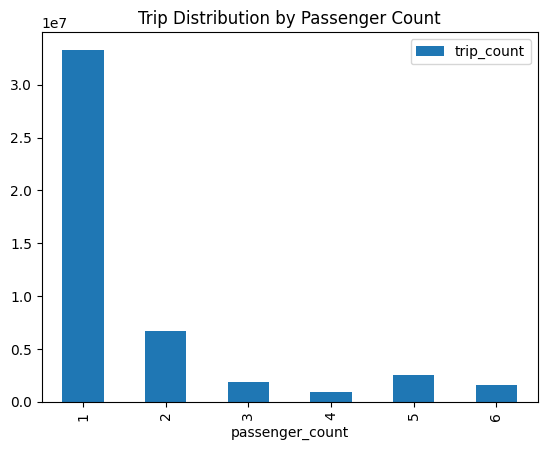

In [24]:
import matplotlib.pyplot as plt

df = con.execute("""
SELECT passenger_count, COUNT(*) AS trip_count
FROM taxi_trips_clean
GROUP BY passenger_count
ORDER BY passenger_count
""").df()

df.plot.bar(x="passenger_count", y="trip_count")
plt.title("Trip Distribution by Passenger Count")
plt.show()

In [25]:
con.execute("""
SELECT COUNT(*) AS total_trips
FROM taxi_trips
""").df()

,total_trips
0,47248845


In [26]:
con.execute("""
SELECT
    EXTRACT(hour FROM tpep_pickup_datetime) AS pickup_hour,
    COUNT(*) AS trip_count
FROM taxi_trips_clean
GROUP BY pickup_hour
ORDER BY pickup_hour
""").df()

,pickup_hour,trip_count
0,0,1678680
1,1,1235300
2,2,909236
3,3,680802
4,4,505927
5,5,469952
6,6,1024745
7,7,1746667
8,8,2143975
9,9,2162325
